In [1]:
from paths import HOME_DIR  # Zenodo release shim
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import pickle as pkl

import torch
from tqdm import tqdm
import numpy as np
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.font_manager as font_manager
import pandas as pd
import json

# optional: clearer CUDA errors
# os.environ.setdefault("CUDA_LAUNCH_BLOCKING", "1")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# ============================================================================
# Styling Constants
# ============================================================================
DEFAULT_DPI = 300
FIG_WIDTH = 3.25/2  # Width for single panel figures
FIG_HEIGHT = FIG_WIDTH  # Height for single panel figures
MARKERSIZE = 10
scatter_marker_size = MARKERSIZE
fontsize = 8

# Plot styling constants
GRID_ALPHA = 0.3
HIST_ALPHA = 0.3
KDE_LINEWIDTH = 1.25
LEGEND_FRAME_EDGECOLOR = "none"  # Transparent edge
LEGEND_FRAME_BOXSTYLE = "Square"
LEGEND_FRAME_PAD = 0

# Model configuration
MODEL_SIZE = "4x4x4"  # CuAu supercell size
NUM_SITES = 64
output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

# HOME_DIR provided by paths shim (Zenodo release)


In [3]:
all_temps = np.array([500, 680, 1200])
all_chem_pots = np.array([0.0])

# output_folder = Path("outputs/analysis/1022_cuau_chempot_multiple_eval")
# output_folder.mkdir(parents=True, exist_ok=True)

Load previously saved results from scripts and plot

In [4]:
# MDNS
mdns_outputs = [
    HOME_DIR / "slurm_files/2026_0124_mdns_cuau_4x4x4_500_temp_field_0.0_wdce_resample_10_num_repl_16_no_metadynamics_batch_size_128_embedding_size_64_layers_4/sampling/mdns_results.pkl",
    HOME_DIR / "slurm_files/2026_0109_mdns_cuau_4x4x4_crit_temp_wdce_5_steps_16_replicates/eval/mdns_results.pkl",
    HOME_DIR / "slurm_files/2026_0109_mdns_cuau_4x4x4_high_temp_wdce_5_steps_16_replicates/eval/mdns_results.pkl",
]
mdns_configs = {}
mdns_energies = {}
mdns_Au_conc = {}
mdns_log_rw = {}
mdns_ness = {}
mdns_free_energies = {}
for mdns_output in mdns_outputs:
    with open(mdns_output, "rb") as f:
        results_dict = pkl.load(f)  # results_dict is a dict of dicts
        mdns_configs.update(results_dict["configs"])
        mdns_energies.update(results_dict["energies"])
        mdns_Au_conc.update(results_dict["x_up"])
        # mdns_log_rw.update(results_dict["log_rnd"])
        mdns_log_rw.update(results_dict["log_rw"])
        mdns_ness.update(results_dict["ness"])
        mdns_free_energies.update(results_dict["free_energies"])

# MetaDNS
metadns_outputs = [
    # 500K low temp NESS a bit low right now, can try again later (high variance per sample)
    HOME_DIR / "slurm_files/2026_0125_mdns_cuau_4x4x4_low_temp_field_0.0_wdce_resample_5_num_repl_16_metadynamics_cv_composition_sigma_0.05_height_0.02154_factor_10_no_scale_bias_batch_size_128_embedding_size_64_layers_4/sampling/mdns_results.pkl",
    HOME_DIR / "slurm_files/2026_0111_mdns_cuau_4x4x4_crit_temp_wdce_resample_5_num_repl_16_metadynamics_sigma_0.05_height_0.0293_factor_10_no_scale_bias_batch_size_128_embedding_size_64_layers_4/sampling/mdns_results.pkl",
    HOME_DIR / "slurm_files/2026_0111_mdns_cuau_4x4x4_high_temp_wdce_resample_5_num_repl_16_metadynamics_sigma_0.05_height_0.0517_factor_10_no_scale_bias_batch_size_128_embedding_size_64_layers_4/sampling/mdns_results.pkl",
]
metadns_configs = {}
metadns_energies = {}
metadns_Au_conc = {}
metadns_log_rw = {}
metadns_ness = {}
metadns_free_energies = {}
metadns_weights = {}
for metadns_output in metadns_outputs:
    with open(metadns_output, "rb") as f:
        results_dict = pkl.load(f)  # results_dict is a dict of dicts
        metadns_configs.update(results_dict["configs"])
        metadns_energies.update(results_dict["energies"])
        metadns_Au_conc.update(results_dict["x_up"])
        # metadns_log_rw.update(results_dict["log_rnd"])
        metadns_log_rw.update(results_dict["log_rw"])
        metadns_ness.update(results_dict["ness"])
        metadns_free_energies.update(results_dict["free_energies"])
        metadns_weights.update(results_dict["weights"])

# SGC MCMC
mcmc_output_dir = HOME_DIR / "benchmarks/outputs/cuau/4x4x4_mcmc"
metadata_path = mcmc_output_dir / "metadata.json"
with metadata_path.open("r", encoding="utf-8") as f:
    mcmc_metadata = json.load(f)

mcmc_configs_blocks = defaultdict(list)
mcmc_energies_blocks = defaultdict(list)
mcmc_Au_conc_blocks = defaultdict(list)

for block_entry in mcmc_metadata["blocks"]:
    block_path = (metadata_path.parent / Path(block_entry["path"]).name)
    with block_path.open("rb") as f:
        block_data = pkl.load(f)
    for key, arr in block_data["configs"].items():
        mcmc_configs_blocks[key].append(arr)
    for key, arr in block_data["energies"].items():
        mcmc_energies_blocks[key].append(arr)
    for key, arr in block_data["x_up"].items():
        mcmc_Au_conc_blocks[key].append(arr)

mcmc_configs = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in mcmc_configs_blocks.items()
}
mcmc_energies = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in mcmc_energies_blocks.items()
}
mcmc_Au_conc = {
    key: {
        "blocks": arrs,
        "all": np.concatenate(arrs, axis=0),
    }
    for key, arrs in mcmc_Au_conc_blocks.items()
}

In [5]:
# Low temp let's use this
wt_metad_outputs = [
    HOME_DIR / "benchmarks/outputs/cuau_4x4x4_wt_metad/lowK_composition_bh0_02154/cuau_biased_samples.pkl"
]
wt_metad_configs = {}
wt_metad_energies = {}
wt_metad_Au_conc = {}
wt_metad_weights = {}
wt_metad_ness = {}
wt_metad_free_energies = {}
for wt_metad_output in wt_metad_outputs:
    with open(wt_metad_output, "rb") as f:
        results_dict = pkl.load(f)  # results_dict is a dict of dicts
        wt_metad_configs.update(results_dict["configs"])
        wt_metad_energies.update(results_dict["energies"])
        wt_metad_Au_conc.update(results_dict["x_up"])
        wt_metad_weights.update(results_dict["weights"])

In [6]:
# ============================================================================
# Compute Statistics: x_Au (Au Concentration) and ESS
# ============================================================================

# Define temperatures for statistics
# Use available temperatures from the data
# Available keys show: 200K, 680K, 1200K
temp_low = 500.0  # Lowest temperature
temp_critical = 680.0  # Middle temperature
temp_high = 1200.0  # Highest temperature
beta_low = 1.0 / temp_low
beta_critical = 1.0 / temp_critical
beta_high = 1.0 / temp_high

# Which MCMC block to use for reference
mc_block_idx = -1  # Use last block (most converged)

# Initialize results dictionary
stats_results = {
    'MDNS': {'critical': {}, 'low': {}, 'high': {}},
    'MetaDNS': {'critical': {}, 'low': {}, 'high': {}},
    'WT-MetaDNS': {'critical': {}, 'low': {}, 'high': {}},
    'MCMC': {'critical': {}, 'low': {}, 'high': {}}
}

# Helper function for systematic resampling (SMC-style)


def systematic_resample(weights, n_samples=None):
    """
    Systematic resampling for Sequential Monte Carlo.

    Parameters:
    -----------
    weights : np.ndarray
        Normalized importance weights, shape (n_samples,)
    n_samples : int, optional
        Number of samples to resample. If None, uses len(weights)

    Returns:
    --------
    np.ndarray
        Indices of resampled particles, shape (n_samples,)
    """
    weights = np.asarray(weights, dtype=np.float64)
    if n_samples is None:
        n_samples = len(weights)

    # Ensure weights are normalized
    weights = weights / weights.sum()

    # Systematic resampling
    u = np.random.uniform(0, 1.0 / n_samples)
    cumulative_weights = np.cumsum(weights)
    indices = np.zeros(n_samples, dtype=np.int64)

    j = 0
    for i in range(n_samples):
        u_i = u + i / n_samples
        while u_i > cumulative_weights[j]:
            j += 1
        indices[i] = j

    return indices

# Helper function to compute ESS from log weights


def compute_ess(log_weights):
    """Compute Effective Sample Size from log weights."""
    log_weights = np.asarray(log_weights, dtype=np.float64)
    # Use log-sum-exp trick
    max_log_weight = np.max(log_weights)
    weights = np.exp(log_weights - max_log_weight)
    weights = weights / weights.sum()
    # ESS = (Σ w_i)^2 / Σ w_i^2
    ess = (np.sum(weights))**2 / np.sum(weights **
                                        2) if np.sum(weights**2) > 0 else 0
    return ess

# Helper function to find closest matching key


def find_closest_key(target_temp, available_keys, key_format="cuau"):
    """Find the closest matching key based on temperature."""
    if not available_keys:
        return None

    # Extract temperatures from keys
    best_key = None
    min_diff = float('inf')

    for key in available_keys:
        try:
            if key_format == "cuau":
                # Format: "200.0K_mu0.00"
                temp_str = key.split('K_')[0]
            else:
                temp_str = key.split('K_')[0]
            key_temp = float(temp_str)
            diff = abs(key_temp - target_temp)
            if diff < min_diff:
                min_diff = diff
                best_key = key
        except (ValueError, IndexError):
            continue

    # Only return if within reasonable tolerance (10 K to handle rounding)
    if min_diff < 10.0:
        return best_key
    return None


# Debug: Print available keys to help diagnose matching issues
print("Available MDNS keys:", list(mdns_configs.keys())
      [:5] if mdns_configs else "None")
print("Available MetaDNS keys:", list(metadns_configs.keys())
      [:5] if metadns_configs else "None")
print("Available MCMC keys:", list(mcmc_configs.keys())
      [:5] if mcmc_configs else "None")
print()

# Process each temperature condition
for beta_val, temp_val, temp_key in [(beta_high, temp_high, 'high'),
                                     (beta_critical, temp_critical, 'critical'),
                                     (beta_low, temp_low, 'low')]:
    # CuAu format: "200.0K_mu0.00" (1 decimal place for temperature)
    temp_key_str_base = f"{temp_val:.1f}K_mu0.00"

    # Find matching keys for each method (may differ slightly)
    mdns_key_str = temp_key_str_base
    if mdns_key_str not in mdns_configs and mdns_configs:
        mdns_key_str = find_closest_key(
            temp_val, list(mdns_configs.keys()), "cuau")
        if mdns_key_str:
            print(
                f"  Using closest MDNS key: '{mdns_key_str}' for temp={temp_val:.1f}")
        else:
            mdns_key_str = None

    metadns_key_str = temp_key_str_base
    if metadns_key_str not in metadns_configs and metadns_configs:
        metadns_key_str = find_closest_key(
            temp_val, list(metadns_configs.keys()), "cuau")
        if metadns_key_str:
            print(
                f"  Using closest MetaDNS key: '{metadns_key_str}' for temp={temp_val:.1f}")
        else:
            metadns_key_str = None

    wt_metad_key_str = temp_key_str_base
    if wt_metad_key_str not in wt_metad_configs and wt_metad_configs:
        wt_metad_key_str = find_closest_key(
            temp_val, list(wt_metad_configs.keys()), "cuau")
        if wt_metad_key_str:
            print(
                f"  Using closest WT-MetaDNS key: '{wt_metad_key_str}' for temp={temp_val:.1f}")
        else:
            wt_metad_key_str = None

    mcmc_key_str = temp_key_str_base
    if mcmc_key_str not in mcmc_configs and mcmc_configs:
        mcmc_key_str = find_closest_key(
            temp_val, list(mcmc_configs.keys()), "cuau")
        if mcmc_key_str:
            print(
                f"  Using closest MCMC key: '{mcmc_key_str}' for temp={temp_val:.1f}")
        else:
            mcmc_key_str = None

    print(
        f"Using keys: mdns='{mdns_key_str}', metadns='{metadns_key_str}', mcmc='{mcmc_key_str}'")

    # Use MCMC as reference (ground truth)
    if mcmc_key_str and mcmc_key_str in mcmc_configs:
        # Get x_Au from pre-computed values
        mcmc_x_Au_blocks = mcmc_Au_conc[mcmc_key_str]["blocks"]
        mcmc_x_Au = mcmc_x_Au_blocks[mc_block_idx]

        # Convert to numpy if needed
        if isinstance(mcmc_x_Au, torch.Tensor):
            mcmc_x_Au = mcmc_x_Au.cpu().numpy()
        mcmc_x_Au = np.asarray(mcmc_x_Au)

        # Average x_Au over samples
        mcmc_x_Au_mean = float(np.mean(mcmc_x_Au))

        stats_results['MCMC'][temp_key] = {
            'x_Au': mcmc_x_Au_mean,
            'ess': None  # MCMC doesn't have ESS
        }
    else:
        print(f"Warning: MCMC data not found for {mcmc_key_str}")
        pass

    # Process MDNS
    print(
        f"  MDNS: mdns_key_str in mdns_configs? {mdns_key_str in mdns_configs if mdns_key_str else False}")
    if mdns_key_str and mdns_key_str in mdns_configs:
        # Get x_Au from pre-computed values
        if mdns_key_str in mdns_Au_conc:
            mdns_x_Au = mdns_Au_conc[mdns_key_str]
        else:
            # Fallback: compute from configs if not pre-computed
            mdns_samples = torch.tensor(
                mdns_configs[mdns_key_str], dtype=torch.long)
            # x_Au is the mean of configs (assuming 0=Cu, 1=Au)
            mdns_x_Au = mdns_samples.float().mean(dim=1).cpu().numpy()

        # Convert to numpy if needed
        if isinstance(mdns_x_Au, torch.Tensor):
            mdns_x_Au = mdns_x_Au.cpu().numpy()
        mdns_x_Au = np.asarray(mdns_x_Au)

        # Average x_Au over samples
        mdns_x_Au_mean = float(np.mean(mdns_x_Au))

        # Get ESS from pre-loaded ness dictionary
        if mdns_key_str in mdns_ness:
            ess = mdns_ness[mdns_key_str]
            if isinstance(ess, torch.Tensor):
                ess = ess.item() if ess.numel() == 1 else ess.cpu().numpy()
            elif isinstance(ess, np.ndarray):
                ess = ess.item() if ess.size == 1 else ess
        else:
            ess = None

        stats_results['MDNS'][temp_key] = {
            'x_Au': mdns_x_Au_mean,
            'ess': ess
        }

    # Process MetaDNS (with importance sampling resampling)
    print(
        f"  MetaDNS: metadns_key_str in metadns_configs? {metadns_key_str in metadns_configs if metadns_key_str else False}")
    if metadns_key_str and metadns_key_str in metadns_configs:
        # Get x_Au from pre-computed values
        if metadns_key_str in metadns_Au_conc:
            metadns_x_Au = metadns_Au_conc[metadns_key_str]
        else:
            # Fallback: compute from configs if not pre-computed
            metadns_samples = torch.tensor(
                metadns_configs[metadns_key_str], dtype=torch.long)
            # x_Au is the mean of configs (assuming 0=Cu, 1=Au)
            metadns_x_Au = metadns_samples.float().mean(dim=1).cpu().numpy()

        # Get log weights and resample if available
        if metadns_key_str in metadns_log_rw:
            log_weights = metadns_log_rw[metadns_key_str]
            if isinstance(log_weights, torch.Tensor):
                log_weights = log_weights.cpu().numpy()
            log_weights = np.asarray(log_weights, dtype=np.float64)
            # Compute weights
            max_log_weight = np.max(log_weights)
            weights = np.exp(log_weights - max_log_weight)
            weights = weights / weights.sum()

            # Resample using systematic resampling
            resampled_indices = systematic_resample(
                weights, n_samples=len(weights))
            # Convert to numpy if needed
            if isinstance(metadns_x_Au, torch.Tensor):
                metadns_x_Au = metadns_x_Au.cpu().numpy()
            metadns_x_Au = np.asarray(metadns_x_Au)
            metadns_x_Au = metadns_x_Au[resampled_indices]
        else:
            # Convert to numpy if needed
            if isinstance(metadns_x_Au, torch.Tensor):
                metadns_x_Au = metadns_x_Au.cpu().numpy()
            metadns_x_Au = np.asarray(metadns_x_Au)

        # Average x_Au over samples
        metadns_x_Au_mean = float(np.mean(metadns_x_Au))

        # Get ESS from pre-loaded ness dictionary
        if metadns_key_str in metadns_ness:
            ess = metadns_ness[metadns_key_str]
            if isinstance(ess, torch.Tensor):
                ess = ess.item() if ess.numel() == 1 else ess.cpu().numpy()
            elif isinstance(ess, np.ndarray):
                ess = ess.item() if ess.size == 1 else ess
        else:
            ess = None

        stats_results['MetaDNS'][temp_key] = {
            'x_Au': metadns_x_Au_mean,
            'ess': ess
        }

    # Process WT-MetaDNS
    print(
        f"  WT-MetaDNS: wt_metad_key_str in wt_metad_configs? {wt_metad_key_str in wt_metad_configs if wt_metad_key_str else False}")
    if wt_metad_key_str and wt_metad_key_str in wt_metad_configs:
        # Get x_Au from pre-computed values
        if wt_metad_key_str in wt_metad_Au_conc:
            wt_metad_x_Au = wt_metad_Au_conc[wt_metad_key_str]
        else:
            # Fallback: compute from configs if not pre-computed
            wt_metad_samples = torch.tensor(
                wt_metad_configs[wt_metad_key_str], dtype=torch.long)
            # x_Au is the mean of configs (assuming 0=Cu, 1=Au)
            wt_metad_x_Au = wt_metad_samples.float().mean(dim=1).cpu().numpy()

        # Get log weights and resample if available
        if wt_metad_key_str in wt_metad_weights:
            # log_weights = wt_metad_weights[wt_metad_key_str]
            # if isinstance(log_weights, torch.Tensor):
            #     log_weights = log_weights.cpu().numpy()
            # log_weights = np.asarray(log_weights, dtype=np.float64)
            # # Compute weights
            # max_log_weight = np.max(log_weights)
            # weights = np.exp(log_weights - max_log_weight)
            # weights = weights / weights.sum()
            weights = wt_metad_weights[wt_metad_key_str]

            # Resample using systematic resampling
            resampled_indices = systematic_resample(
                weights, n_samples=len(weights))
            # Convert to numpy if needed
            if isinstance(wt_metad_x_Au, torch.Tensor):
                wt_metad_x_Au = wt_metad_x_Au.cpu().numpy()
            wt_metad_x_Au = np.asarray(wt_metad_x_Au)
            wt_metad_x_Au = wt_metad_x_Au[resampled_indices]
        else:
            # Convert to numpy if needed
            if isinstance(wt_metad_x_Au, torch.Tensor):
                wt_metad_x_Au = wt_metad_x_Au.cpu().numpy()
            wt_metad_x_Au = np.asarray(wt_metad_x_Au)

        # Average x_Au over samples
        wt_metad_x_Au_mean = float(np.mean(wt_metad_x_Au))

        # Get ESS from pre-loaded ness dictionary
        if wt_metad_key_str in wt_metad_ness:
            ess = wt_metad_ness[wt_metad_key_str]
            if isinstance(ess, torch.Tensor):
                ess = ess.item() if ess.numel() == 1 else ess.cpu().numpy()
            elif isinstance(ess, np.ndarray):
                ess = ess.item() if ess.size == 1 else ess
        else:
            ess = None

        stats_results['WT-MetaDNS'][temp_key] = {
            'x_Au': wt_metad_x_Au_mean,
            'ess': ess
        }

# Print results in table format
print("\n" + "="*80)
print("Statistics Table: x_Au (Au Concentration) and ESS")
print("="*80)
print(f"{'Method':<12} {'β':<12} {'T (K)':<10} {'x_Au':<15} {'ESS':<10}")
print("-"*80)

for method in ['MDNS', 'MetaDNS', 'WT-MetaDNS', 'MCMC']:
    for temp_key, beta_val, temp_val in [('high', beta_high, temp_high),
                                         ('critical', beta_critical, temp_critical),
                                         ('low', beta_low, temp_low)]:
        if method in stats_results and temp_key in stats_results[method]:
            stats = stats_results[method][temp_key]
            # Check if stats dictionary has the required keys
            if 'x_Au' in stats:
                x_Au_str = f"{stats['x_Au']:.4f}" if stats['x_Au'] is not None else "N/A"
                ess_str = f"{stats['ess']:.3f}" if stats['ess'] is not None else "N/A"
                print(
                    f"{method:<12} β={beta_val:<8.4f} {temp_val:<10.1f} {x_Au_str:<15} {ess_str:<10}")

print("="*80)
print("\nNote: x_Au is the Au concentration (equivalent to absolute magnetization for spin systems)")
print("ESS is from pre-computed ness values (only for MDNS and MetaDNS)")

Available MDNS keys: ['500.0000K_h0.0000', '680.0000K_h0.0000', '1200.0000K_h0.0000']
Available MetaDNS keys: ['500.0000K_h0.0000', '680.0000K_h0.0000', '1200.0000K_h0.0000']
Available MCMC keys: ['200.0K_mu0.00', '500.0K_mu0.00', '600.0K_mu0.00', '680.0K_mu0.00', '1200.0K_mu0.00']

  Using closest MDNS key: '1200.0000K_h0.0000' for temp=1200.0
  Using closest MetaDNS key: '1200.0000K_h0.0000' for temp=1200.0
Using keys: mdns='1200.0000K_h0.0000', metadns='1200.0000K_h0.0000', mcmc='1200.0K_mu0.00'
  MDNS: mdns_key_str in mdns_configs? True
  MetaDNS: metadns_key_str in metadns_configs? True
  WT-MetaDNS: wt_metad_key_str in wt_metad_configs? False
  Using closest MDNS key: '680.0000K_h0.0000' for temp=680.0
  Using closest MetaDNS key: '680.0000K_h0.0000' for temp=680.0
Using keys: mdns='680.0000K_h0.0000', metadns='680.0000K_h0.0000', mcmc='680.0K_mu0.00'
  MDNS: mdns_key_str in mdns_configs? True
  MetaDNS: metadns_key_str in metadns_configs? True
  WT-MetaDNS: wt_metad_key_str in w

In [7]:
mcmc_configs_blocks.keys()

dict_keys(['200.0K_mu0.00', '500.0K_mu0.00', '600.0K_mu0.00', '680.0K_mu0.00', '1200.0K_mu0.00'])

In [8]:
# Print NESS in the format of "temp: NESS:.3f"
print(
    f"MDNS NESS: {[f'{k[:3]}K' + ': ' + f'{v:.3f}' for k, v in mdns_ness.items()]}")
print(
    f"MetaDNS NESS: {[f'{k[:3]}K' + ': ' + f'{v:.3f}' for k, v in metadns_ness.items() if 'physical' not in k]}")

MDNS NESS: ['500K: 0.976', '680K: 0.402', '120K: 0.787']
MetaDNS NESS: ['500K: 0.026', '680K: 0.176', '120K: 0.517']


In [9]:
# ============================================================================
# Plot Styling: Markers and Colors
# ============================================================================

# Marker scheme: Method-based (same shape for same method across architectures)
# - train methods: square (s)
# - Paint methods: triangle down (v) - same for all architectures
# - Reference methods: circles (o) and squares (s)
marker_dict = {
    "MDNS": "s",
    "MetaDNS": "s",

    # ARM
    "ARM": "s",

    # Reference methods
    "Wang-Landau": "s",
    "SW": "s",
    "MCMC": "o",
    "ARM-MCMC": "o",
    "Exact": "s",
}

# Color scheme: User-specified colors based on custom matplotlib color cycle
color_dict = {
    "MDNS": "C1",  # Light blue
    "MetaDNS": "C0",   # Dark blue for MAM GNN

    # ARM
    "ARM": "C2",  # Green

    # Reference methods
    "Wang-Landau": "C5",  # Dark gray (#495567)
    "MCMC": "C5",  # Gray
    "Exact": "C5",  # Dark gray
    "SW": "C3",  # Red
}

In [10]:
# ============================================================================
# Plot Styling Helper Functions
# ============================================================================
from matplotlib.colors import to_rgba


def resolve_color(name: str, default: str = "C0") -> str:
    """Return the best matching palette color for a label.

    Parameters
    ----------
    name : str
        Method/model name to match against color_dict keys.
    default : str, optional
        Default color to return if no match is found.

    Returns
    -------
    str
        Color specification (e.g., "C0", "C1", etc.).
    """
    resolved = default
    for color_key, color in color_dict.items():
        if color_key in name:
            resolved = color
            break
    return resolved


def format_subplot_title(temp: float, chem_pot: float = None) -> str:
    """Format subplot title with LaTeX math formatting.

    Parameters
    ----------
    temp : float
        Temperature value.
    chem_pot : float
        Chemical potential value.

    Returns
    -------
    str
        Formatted title string with LaTeX.
    """
    if chem_pot is not None:
        return rf"$T = {temp:3d} K$, $\mu = {chem_pot:.1f}$"
    else:
        return rf"$T = {temp:3d} K$"


def style_subplot_axes(
    ax, xlabel: str = None, ylabel: str = None, title: str = None, grid: bool = True
):
    """Apply consistent styling to subplot axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes object to style.
    xlabel : str, optional
        X-axis label.
    ylabel : str, optional
        Y-axis label.
    title : str, optional
        Subplot title.
    grid : bool, default=True
        Whether to show grid.
    """
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=fontsize)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=fontsize)
    if title is not None:
        ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize)
    if grid:
        ax.grid(True, alpha=GRID_ALPHA)


def create_legend(
    fig,
    ax,
    handles=None,
    labels=None,
    loc: str = "upper right",
    bbox_to_anchor=None,
    frameon: bool = True,
):
    """Create a consistently styled legend.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object.
    ax : matplotlib.axes.Axes or array of axes
        Axes object(s) for bbox_to_anchor calculation.
    handles : list, optional
        Legend handles. If None, uses handles from ax.
    labels : list, optional
        Legend labels. If None, uses labels from handles.
    loc : str, default="upper right"
        Legend location.
    bbox_to_anchor : tuple, optional
        Bbox specification for legend placement.
    frameon : bool, default=True
        Whether to show legend frame.

    Returns
    -------
    matplotlib.legend.Legend
        Styled legend object.
    """
    if handles is None and labels is None:
        # Extract from axes if not provided
        # For subplot grids, labels are typically in the first panel (top-left)
        if hasattr(ax, "shape"):
            # numpy array of axes - use top-left (first) panel
            ax_ref = ax.flat[0] if hasattr(ax, "flat") else ax[0, 0]
        elif hasattr(ax, "__iter__") and not isinstance(ax, (str, bytes)):
            # List or other iterable of axes - use first one
            ax_ref = ax[0]
        else:
            # Single axes object
            ax_ref = ax
        handles, labels = ax_ref.get_legend_handles_labels()
        # Filter out None labels (which indicate no legend entry)
        if handles and labels:
            filtered = [
                (h, l) for h, l in zip(handles, labels) if l is not None and l != ""
            ]
            if filtered:
                handles, labels = zip(*filtered)
                handles, labels = list(handles), list(labels)

    if labels is None and handles is not None:
        labels = [h.get_label() for h in handles]
        # Filter out empty labels
        if labels:
            filtered = [(h, l)
                        for h, l in zip(handles, labels) if l and l != ""]
            if filtered:
                handles, labels = zip(*filtered)
                handles, labels = list(handles), list(labels)

    # Only create legend if we have handles and labels
    if not handles or not labels:
        return None

    # Determine bbox_transform for subplot grids
    if bbox_to_anchor is None and hasattr(ax, "shape"):
        # Default bbox for subplot grids - use top-right corner
        bbox_to_anchor = (1, 1)
        # Get the top-right panel for transform
        if hasattr(ax, "flat"):
            nrows, ncols = ax.shape
            ax_ref = ax[0, -1] if nrows > 0 and ncols > 0 else ax.flat[0]
        else:
            ax_ref = ax[0, -1] if len(ax.shape) == 2 else ax.flat[0]
        bbox_transform = ax_ref.transAxes
    else:
        bbox_transform = None

    if bbox_transform is not None:
        legend = fig.legend(
            handles,
            labels,
            loc=loc,
            bbox_to_anchor=bbox_to_anchor,
            bbox_transform=bbox_transform,
            frameon=frameon,
            fontsize=fontsize,
        )
    else:
        legend = fig.legend(
            handles, labels, loc=loc, frameon=frameon, fontsize=fontsize
        )

    # Apply consistent frame styling
    if frameon and legend is not None:
        legend.get_frame().set_edgecolor(LEGEND_FRAME_EDGECOLOR)
        legend.get_frame().set_boxstyle(LEGEND_FRAME_BOXSTYLE, pad=LEGEND_FRAME_PAD)

    return legend


def interpolate_colors(color_a, color_b, fractions, *, cmap=None):
    """Interpolate between two Matplotlib colors.

    Parameters
    ----------
    color_a, color_b : str or tuple
        Color specifications understood by Matplotlib (e.g. "C0", "#ff0000", (0.2, 0.4, 0.6)).
    fractions : float or array-like of float
        Values between 0 and 1 indicating the interpolation weight. ``0`` returns ``color_a``;
        ``1`` returns ``color_b``.
    cmap : callable, optional
        If provided, applies the callable (e.g., ``matplotlib.colors.to_hex``) to the interpolated
        rgba values before returning.

    Returns
    -------
    np.ndarray or object
        Interpolated colors in RGBA form unless ``cmap`` is provided.
    """
    frac = np.asarray(fractions, dtype=float)
    if np.any((frac < 0) | (frac > 1)):
        raise ValueError("fractions must lie in [0, 1].")

    rgba_a = np.array(to_rgba(color_a))
    rgba_b = np.array(to_rgba(color_b))
    blended = np.outer(1 - frac, rgba_a) + np.outer(frac, rgba_b)

    if blended.ndim == 1:
        blended = blended[np.newaxis, :]

    if cmap is not None:
        return np.array([cmap(rgba) for rgba in blended])

    return blended.squeeze()

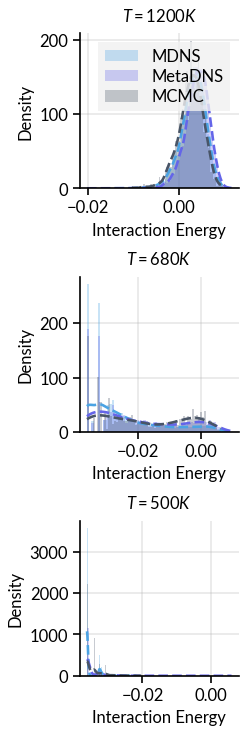

In [11]:
# ============================================================================
# Plotting Functions
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns


def _safe_hist(ax, data, *, weights=None, label=None, color="C0"):
    """Plot histogram with KDE, handling finite values safely.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to plot on.
    data : array-like
        Data to histogram.
    weights : array-like, optional
        Weights for histogram.
    label : str, optional
        Label for legend.
    color : str, default="C0"
        Color for histogram.
    """
    values = np.asarray(data, dtype=float)
    mask = np.isfinite(values)
    finite_vals = values[mask]
    finite_weights = None
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        finite_weights = weights[mask]
        if finite_weights.sum() > 0:
            finite_weights = finite_weights / finite_weights.sum()
        else:
            finite_weights = None
    kde_ok = finite_vals.size > 1 and np.nanstd(finite_vals) > 1e-8
    sns.histplot(
        x=finite_vals,
        bins=NUM_SITES,
        stat="density",
        ax=ax,
        weights=finite_weights,
        label=label,
        kde=kde_ok,
        lw=0,
        color=color,
        alpha=HIST_ALPHA,
        line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH} if kde_ok else None,
    )


# ============================================================================
# Plot: Interaction Energy Distributions
# ============================================================================
mc_block_idx = -1  # Which block to use for MCMC
sample_size = 1000

fig, ax = plt.subplots(
    len(all_temps),
    len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained",
)
# fig.suptitle(
#     f"{MODEL_SIZE} CuAu Interaction Energy Distributions", fontsize=12, weight="bold"
# )

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        mdns_key = f"{temp:.4f}K_h{chem_pot:.4f}"
        energy_scale = 1 / NUM_SITES

        # Sample data and plot histograms
        base_labels = ("ARM", "MDNS", "MetaDNS", "MCMC", "SW") if (
            i == 0 and j == 0) else (None, None, None, None, None)
        if mdns_key in mdns_energies:
            # mdns
            color = color_dict.get("MDNS", "C0")
            sns.histplot(
                x=mdns_energies[mdns_key] * energy_scale, bins=NUM_SITES, stat="density", ax=ax[i, j],
                label=base_labels[1], kde=True, lw=0,
                color=color,
                alpha=HIST_ALPHA,
                line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH}
            )
            # metadns
            color = color_dict.get("MetaDNS", "C0")
            sns.histplot(
                x=metadns_energies[mdns_key] * energy_scale, bins=NUM_SITES, stat="density", ax=ax[i, j],
                weights=metadns_weights[mdns_key],
                label=base_labels[2], kde=True, lw=0,
                color=color,
                alpha=HIST_ALPHA,
                line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH}
            )

        # MCMC
        _safe_hist(ax[i, j], mcmc_energies[key]["blocks"][mc_block_idx] * energy_scale, label=base_labels[3],
                   color=color_dict["MCMC"])

        # Style subplot
        style_subplot_axes(
            ax[i, j],
            xlabel="Interaction Energy",
            title=format_subplot_title(temp),
        )
        # ax[i, j].set_ylim(0, 3.0)

create_legend(fig, ax)
fig.savefig(
    f"{output_dir}/{MODEL_SIZE}_cuau_interaction_energy_distributions.pdf",
    bbox_inches="tight",
)
fig.show()

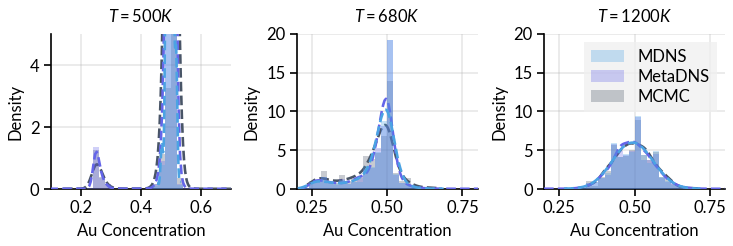

In [12]:
# ============================================================================
# Plot: Au Concentration Distributions
# ============================================================================
fig, ax = plt.subplots(
    len(all_chem_pots),
    len(all_temps),
    figsize=(FIG_WIDTH * len(all_temps), FIG_HEIGHT * len(all_chem_pots)),
    layout="constrained",
)
# fig.suptitle(
#     f"{MODEL_SIZE} CuAu Model Au Concentration Distributions",
#     fontsize=12,
#     weight="bold",
# )

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_temps) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_chem_pots) == 1:
        ax = ax[np.newaxis, :]

for i, chem_pot in enumerate(all_chem_pots):
    for j, temp in enumerate(all_temps):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        mdns_key = f"{temp:.4f}K_h{chem_pot:.4f}"

        # Plot histograms (only label in top-left panel)
        is_first_panel = (i == 0 and j == 0)
        labels = ("ARM", "MDNS", "MetaDNS", "MCMC", "SW") if is_first_panel else (
            None, None, None, None, None)

        if mdns_key in mdns_Au_conc:
            # mdns
            color = color_dict.get("MDNS", "C0")
            # Use larger bandwidth for smoother KDE, especially at low temperatures
            # bw_adjust > 1 increases smoothing (default is 1.0)
            kde_bw_adjust = 3.5 if temp == 500 else 2
            sns.histplot(
                x=mdns_Au_conc[mdns_key],  bins=min(NUM_SITES, 50), stat="density", ax=ax[i, j],
                label=labels[1], kde=True, lw=0,
                binrange=(0, 1),
                color=color,
                alpha=HIST_ALPHA,
                kde_kws={"bw_adjust": kde_bw_adjust},
                line_kws={"linestyle": "--",
                          "lw": KDE_LINEWIDTH, "zorder": 1000},
                zorder=1000,
            )

        if mdns_key in metadns_Au_conc:
            # metadns
            # likelihood-based importance sampling
            log_weights = metadns_log_rw[mdns_key]
            max_log_weight = np.max(log_weights)
            weights = np.exp(log_weights - max_log_weight)
            weights = weights / weights.sum()

            # bias-based importance sampling
            # weights = metadns_weights[mdns_key]

            color = color_dict.get("MetaDNS", "C0")
            sns.histplot(
                x=metadns_Au_conc[mdns_key], bins=min(NUM_SITES, 50), stat="density", ax=ax[i, j],
                weights=weights,
                label=labels[2], kde=True, lw=0,
                binrange=(0, 1),
                color=color,
                alpha=HIST_ALPHA,
                line_kws={"linestyle": "--",
                          "lw": KDE_LINEWIDTH, "zorder": 10},
                zorder=10,
            )

        if mdns_key in wt_metad_Au_conc:
            # WT-MetaDNS
            # Last minute bootstrap for MCMC at 500K
            color = color_dict.get("SW", "C0")
            sns.histplot(
                x=wt_metad_Au_conc[mdns_key], bins=min(NUM_SITES, 50), stat="density", ax=ax[i, j],
                weights=wt_metad_weights[mdns_key],
                label=labels[3], kde=True, lw=0,
                binrange=(0, 1),
                color=color_dict["MCMC"],
                alpha=HIST_ALPHA,
                line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH, "zorder": 5},
                zorder=5,
            )

        else:
            # MCMC
            sns.histplot(
                x=mcmc_Au_conc[key]["blocks"][mc_block_idx], bins=min(NUM_SITES, 50), stat="density", ax=ax[i, j],
                label=labels[3], kde=True, lw=0,
                binrange=(0, 1),
                color=color_dict["MCMC"],
                alpha=HIST_ALPHA,
                line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH, "zorder": 5},
                zorder=5,
            )

        # SW
        # sns.histplot(
        #     x=sw_x_up[key]["blocks"][mc_block_idx], bins=NUM_SITES, stat="density", ax=ax[i, j],
        #     label=labels[4], kde=True, lw=0,
        #     color=color_dict["SW"],
        #     alpha=HIST_ALPHA,
        #     line_kws={"linestyle": "--", "lw": KDE_LINEWIDTH}
        # )

        # Style subplot
        style_subplot_axes(
            ax[i, j],
            xlabel="Au Concentration",
            title=format_subplot_title(temp),
        )
        ax[i, j].set_xlim(0, 1)
        if i == 0 and j == 0:
            ax[i, j].set_ylim(0, 5)
            ax[i, j].set_xlim(0.1, 0.7)

        else:
            ax[i, j].set_ylim(0, 20)
            ax[i, j].set_xlim(0.2, 0.8)

create_legend(fig, ax)
fig.savefig(
    f"{output_dir}/{MODEL_SIZE}_cuau_up_spin_concentration_distributions.pdf",
    bbox_inches="tight",
)
fig.show()

In [13]:
wt_metad_Au_conc

{'500.0000K_h0.0000': array([0.734375, 0.5     , 0.28125 , ..., 0.546875, 0.609375, 0.25    ],
       dtype=float32)}

In [14]:
wt_metad_weights
# Separate plot with just the MCMC x_Au distribution

{'500.0000K_h0.0000': array([2.1961673e+02, 1.3935011e+11, 9.0250609e+09, ..., 7.3008275e+08,
        4.0398228e+05, 6.9648020e+09], dtype=float32)}

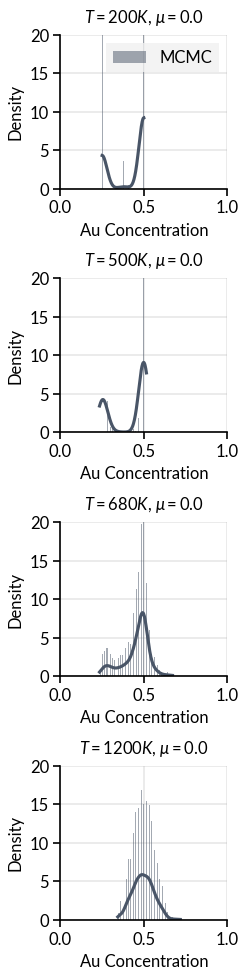

In [15]:
# Separate plot with just the MCMC x_Au distribution
mcmc_temps = [200, 500, 680, 1200]
mcmc_chem_pots = [0.0]

fig, ax = plt.subplots(len(mcmc_temps), len(mcmc_chem_pots), figsize=(
    FIG_WIDTH * len(mcmc_chem_pots), FIG_HEIGHT * len(mcmc_temps)), layout="constrained")

# Extend the ax to be 2D
if not hasattr(ax, 'ndim'):
    ax = np.array([[ax]])
elif ax.ndim == 1:
    ax = ax[:, np.newaxis]

for i, temp in enumerate(mcmc_temps):
    for j, chem_pot in enumerate(mcmc_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        sns.histplot(
            x=mcmc_Au_conc[key]["blocks"][mc_block_idx], bins=NUM_SITES, stat="density", ax=ax[i, j],
            label="MCMC", kde=True, lw=0,
            color=color_dict["MCMC"],
        )
        style_subplot_axes(
            ax[i, j],
            xlabel="Au Concentration",
            title=format_subplot_title(temp, chem_pot),
        )
        ax[i, j].set_xlim(0, 1)
        ax[i, j].set_ylim(0, 20)

create_legend(fig, ax)
fig.savefig(
    f"{output_dir}/{MODEL_SIZE}_cuau_mcmc_x_au_distribution.pdf",
    bbox_inches="tight",
)
fig.show()

In [16]:
mcmc_Au_conc.keys()

dict_keys(['200.0K_mu0.00', '500.0K_mu0.00', '600.0K_mu0.00', '680.0K_mu0.00', '1200.0K_mu0.00'])

Plot JS divergence over block iterations

In [17]:
# Helper function to calculate JS divergence from raw data arrays
import numpy as np


def js_from_data(
    data_p,
    data_q,
    *,
    bins=None,
    range=None,
    weights_p=None,
    weights_q=None,
    base=None,
    density=True,
):
    """Calculate JS divergence from raw data arrays.

    Parameters
    ----------
    data_p : array-like
        First dataset (e.g., MDNS or MetaDNS)
    data_q : array-like
        Second dataset (e.g., MCMC)
    bins : int or array-like, optional
        Number of bins or bin edges. If None, uses NUM_SITES.
    range : tuple, optional
        Range for histogram bins (min, max). If None, uses data range.
    weights_p : array-like, optional
        Weights for data_p (e.g., for MetaDNS)
    weights_q : array-like, optional
        Weights for data_q
    base : float, optional
        Logarithm base for JS divergence (e.g., 2 for bits)
    density : bool, default=True
        If True, normalize histogram to density

    Returns
    -------
    float
        JS divergence between the two distributions
    """
    data_p = np.asarray(data_p, dtype=np.float64)
    data_q = np.asarray(data_q, dtype=np.float64)

    # Filter finite values
    mask_p = np.isfinite(data_p)
    mask_q = np.isfinite(data_q)

    finite_p = data_p[mask_p]
    finite_q = data_q[mask_q]

    # Handle weights
    finite_weights_p = None
    if weights_p is not None:
        weights_p = np.asarray(weights_p, dtype=np.float64)
        finite_weights_p = weights_p[mask_p]
        if finite_weights_p.sum() > 0:
            finite_weights_p = finite_weights_p / finite_weights_p.sum()
        else:
            finite_weights_p = None

    finite_weights_q = None
    if weights_q is not None:
        weights_q = np.asarray(weights_q, dtype=np.float64)
        finite_weights_q = weights_q[mask_q]
        if finite_weights_q.sum() > 0:
            finite_weights_q = finite_weights_q / finite_weights_q.sum()
        else:
            finite_weights_q = None

    # Determine bins and range
    if range is None:
        data_min = min(finite_p.min(), finite_q.min())
        data_max = max(finite_p.max(), finite_q.max())
        range = (data_min, data_max)

    if bins is None:
        bins = NUM_SITES

    # Create histograms with same bins
    hist_p, bins_p = np.histogram(
        finite_p, bins=bins, range=range, weights=finite_weights_p, density=density
    )
    hist_q, bins_q = np.histogram(
        finite_q, bins=bins, range=range, weights=finite_weights_q, density=density
    )

    # Calculate JS divergence
    return js_from_hist(hist_p, bins_p, hist_q, bins_q, base=base, density=density)


def kl_divergence(p, q, *, base=None, normalize=True):
    """KL(p || q) for nonnegative vectors p, q."""
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    if p.shape != q.shape:
        raise ValueError("Distributions must have the same shape.")
    if np.any(p < 0) or np.any(q < 0):
        raise ValueError("Distributions must be nonnegative.")

    if normalize:
        p_sum = p.sum()
        q_sum = q.sum()
        if p_sum <= 0 or q_sum <= 0:
            raise ValueError(
                "Distributions must have strictly positive total mass.")
        p = p / p_sum
        q = q / q_sum

    mask = p > 0
    if np.any(q[mask] <= 0):
        raise ValueError("q must be positive wherever p is positive.")

    kl = np.sum(p[mask] * (np.log(p[mask]) - np.log(q[mask])))
    if base is not None:
        kl /= np.log(base)
    return kl


def _hist_to_mass(hist, bins, *, density):
    """Convert np.histogram output to bin probabilities (unnormalized mass)."""
    hist = np.asarray(hist, dtype=np.float64)
    bins = np.asarray(bins, dtype=np.float64)

    if bins.shape[0] != hist.shape[0] + 1:
        raise ValueError("Bin edges must have length len(hist) + 1.")

    if density:
        # hist is a density: p_i = f_i * width_i
        widths = np.diff(bins)
        mass = hist * widths
    else:
        # hist is counts: use directly as mass
        mass = hist.astype(np.float64)

    if np.any(mass < 0):
        raise ValueError("Histogram values must be nonnegative.")

    return mass


def kl_from_hist(
    hist_p,
    bins_p,
    hist_q,
    bins_q,
    *,
    base=None,
    density=True,
):
    """KL(P || Q) from np.histogram outputs."""
    hist_p = np.asarray(hist_p, dtype=np.float64)
    hist_q = np.asarray(hist_q, dtype=np.float64)
    bins_p = np.asarray(bins_p, dtype=np.float64)
    bins_q = np.asarray(bins_q, dtype=np.float64)

    if hist_p.shape != hist_q.shape:
        raise ValueError("Histograms must have the same number of bins.")
    if bins_p.shape != bins_q.shape:
        raise ValueError("Bin edge arrays must have the same shape.")
    if not np.allclose(bins_p, bins_q):
        raise ValueError("Bin edges must match for KL divergence.")

    p = _hist_to_mass(hist_p, bins_p, density=density)
    q = _hist_to_mass(hist_q, bins_q, density=density)

    return kl_divergence(p, q, base=base, normalize=True)


def js_from_hist(
    hist_p,
    bins_p,
    hist_q,
    bins_q,
    *,
    base=None,
    density=True,
):
    """Jensen–Shannon divergence between two histograms."""
    hist_p = np.asarray(hist_p, dtype=np.float64)
    hist_q = np.asarray(hist_q, dtype=np.float64)
    bins_p = np.asarray(bins_p, dtype=np.float64)
    bins_q = np.asarray(bins_q, dtype=np.float64)

    if hist_p.shape != hist_q.shape:
        raise ValueError("Histograms must have the same number of bins.")
    if bins_p.shape != bins_q.shape:
        raise ValueError("Bin edge arrays must have the same shape.")
    if not np.allclose(bins_p, bins_q):
        raise ValueError("Bin edges must match for JS divergence.")

    # Convert to (unnormalized) mass in each bin
    p = _hist_to_mass(hist_p, bins_p, density=density)
    q = _hist_to_mass(hist_q, bins_q, density=density)

    # Normalise once here
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)  # already normalised since sum(m) = 1

    # Use KL on already-normalised distributions
    return 0.5 * (
        kl_divergence(p, m, base=base, normalize=False)
        + kl_divergence(q, m, base=base, normalize=False)
    )

In [18]:
# Calculate JS divergence for MDNS and MetaDNS vs MCMC
import numpy as np
# For interaction energies and x_Au (Au concentration)
mc_block_idx = -1  # Which MCMC block to use for comparison
energy_scale = 1 / NUM_SITES

# Storage for results
js_div_results = {
    "MDNS_energy": {},
    "MetaDNS_energy": {},
    "MDNS_x_Au": {},
    "MetaDNS_x_Au": {},
}

for temp in all_temps:
    for chem_pot in all_chem_pots:
        # Key formats
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"  # MCMC key
        mdns_key = f"{temp:.4f}K_h{chem_pot:.4f}"  # MDNS/MetaDNS key

        # Skip if MCMC data doesn't exist
        if key not in mcmc_energies:
            continue

        # Get MCMC data
        mcmc_energy = mcmc_energies[key]["blocks"][mc_block_idx] * energy_scale
        mcmc_x_au = mcmc_Au_conc[key]["blocks"][mc_block_idx]

        # Calculate JS divergence for interaction energies
        if mdns_key in mdns_energies:
            # MDNS vs MCMC (energy)
            js_div_results["MDNS_energy"][mdns_key] = js_from_data(
                mdns_energies[mdns_key] * energy_scale,
                mcmc_energy,
                bins=NUM_SITES,
                density=True,
            )

            # MDNS vs MCMC (x_Au)
            js_div_results["MDNS_x_Au"][mdns_key] = js_from_data(
                mdns_Au_conc[mdns_key],
                mcmc_x_au,
                bins=NUM_SITES,
                density=True,
            )

        if mdns_key in metadns_energies:
            # MetaDNS vs MCMC (energy) - with weights
            js_div_results["MetaDNS_energy"][mdns_key] = js_from_data(
                metadns_energies[mdns_key] * energy_scale,
                mcmc_energy,
                weights_p=metadns_weights[mdns_key],
                bins=NUM_SITES,
                density=True,
            )

            # MetaDNS vs MCMC (x_Au) - with weights
            js_div_results["MetaDNS_x_Au"][mdns_key] = js_from_data(
                metadns_Au_conc[mdns_key],
                mcmc_x_au,
                weights_p=metadns_weights[mdns_key],
                bins=NUM_SITES,
                density=True,
            )

# Print results
print("JS Divergence Results (MDNS/MetaDNS vs MCMC)")
print("=" * 60)
print(f"\nUsing MCMC block index: {mc_block_idx}")
print(f"Energy scale factor: {energy_scale:.4f}")
print("\n" + "-" * 60)

for temp in all_temps:
    for chem_pot in all_chem_pots:
        mdns_key = f"{temp:.4f}K_h{chem_pot:.4f}"
        print(
            f"\nTemperature: {temp:.1f} K, Chemical Potential: {chem_pot:.2f}")
        print(f"  Key: {mdns_key}")

        if mdns_key in js_div_results["MDNS_energy"]:
            print(
                f"  MDNS Energy JS Div:     {js_div_results['MDNS_energy'][mdns_key]:.6f}")
            print(
                f"  MDNS x_Au JS Div:       {js_div_results['MDNS_x_Au'][mdns_key]:.6f}")

        if mdns_key in js_div_results["MetaDNS_energy"]:
            print(
                f"  MetaDNS Energy JS Div:  {js_div_results['MetaDNS_energy'][mdns_key]:.6f}")
            print(
                f"  MetaDNS x_Au JS Div:     {js_div_results['MetaDNS_x_Au'][mdns_key]:.6f}")

print("\n" + "=" * 60)

JS Divergence Results (MDNS/MetaDNS vs MCMC)

Using MCMC block index: -1
Energy scale factor: 0.0156

------------------------------------------------------------

Temperature: 500.0 K, Chemical Potential: 0.00
  Key: 500.0000K_h0.0000
  MDNS Energy JS Div:     0.129184
  MDNS x_Au JS Div:       0.131564
  MetaDNS Energy JS Div:  0.080484
  MetaDNS x_Au JS Div:     0.083439

Temperature: 680.0 K, Chemical Potential: 0.00
  Key: 680.0000K_h0.0000
  MDNS Energy JS Div:     0.041855
  MDNS x_Au JS Div:       0.015850
  MetaDNS Energy JS Div:  0.016543
  MetaDNS x_Au JS Div:     0.021115

Temperature: 1200.0 K, Chemical Potential: 0.00
  Key: 1200.0000K_h0.0000
  MDNS Energy JS Div:     0.011401
  MDNS x_Au JS Div:       0.004322
  MetaDNS Energy JS Div:  0.036473
  MetaDNS x_Au JS Div:     0.005658



In [19]:
# Calculate JS divergence over block iterations for MCMC energy and Au_conc distributions
# At each temperature and chemical potential, calculate the JS divergence between the MCMC energy and Au_conc distributions
# and the ARM and MAM Transformer distributions
js_div_energy = defaultdict(list)
js_div_Au_conc = defaultdict(list)
step_size = 500
step_number_list = []

blocks_length = None  # to accumulate step_number only once

# Visualize MCMC energy and Au_conc distribution changes over block iterations
plot_every = 1
mc_energies_to_plot = defaultdict(list)
mc_Au_conc_to_plot = defaultdict(list)
mc_labels_to_plot = defaultdict(list)
mc_colors_to_plot = defaultdict(list)

for temp in all_temps:
    for chem_pot in all_chem_pots:
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"

        last_block_idx = len(mcmc_energies[key]["blocks"]) - 1
        last_mcmc_energy = mcmc_energies[key]["blocks"][last_block_idx]
        last_mcmc_Au_conc = mcmc_Au_conc[key]["blocks"][last_block_idx]

        min_energy, max_energy = last_mcmc_energy.min(), last_mcmc_energy.max()
        min_Au_conc, max_Au_conc = last_mcmc_Au_conc.min(), last_mcmc_Au_conc.max()

        # Create distributions for last block
        last_mcmc_energy_dist = np.histogram(
            last_mcmc_energy, bins=100, range=(min_energy, max_energy), density=True
        )
        last_mcmc_Au_conc_dist = np.histogram(
            last_mcmc_Au_conc, bins=100, range=(min_Au_conc, max_Au_conc), density=True
        )
        last_energy_bins = last_mcmc_energy_dist[1]
        last_Au_conc_bins = last_mcmc_Au_conc_dist[1]

        if blocks_length is None:
            blocks_length = len(mcmc_energies[key]["blocks"])
            # Only fill step_number_list once (assuming all keys have same length)!
            step_number_list.extend(
                [i * step_size for i in range(blocks_length)])

        for block_idx in range(len(mcmc_energies[key]["blocks"])):
            if block_idx % plot_every == 0:
                mc_energies_to_plot[key].append(
                    mcmc_energies[key]["blocks"][block_idx])
                mc_Au_conc_to_plot[key].append(
                    mcmc_Au_conc[key]["blocks"][block_idx])
                mc_labels_to_plot[key].append(f"MCMC {block_idx * step_size}")
                mc_colors_to_plot[key].append(color_dict["MCMC"])

            current_mcmc_energy = mcmc_energies[key]["blocks"][block_idx]
            current_mcmc_Au_conc = mcmc_Au_conc[key]["blocks"][block_idx]

            # Create distributions for current block using the same bin edges as the reference block
            current_mcmc_energy_dist = np.histogram(
                current_mcmc_energy, bins=last_energy_bins, density=True
            )
            current_mcmc_Au_conc_dist = np.histogram(
                current_mcmc_Au_conc, bins=last_Au_conc_bins, density=True
            )

            # Calculate JS divergence between current MCMC energy and last MCMC energy
            js_div_energy[key].append(
                js_from_hist(*current_mcmc_energy_dist, *last_mcmc_energy_dist)
            )

            # Calculate JS divergence between current MCMC Au_conc and last MCMC Au_conc
            js_div_Au_conc[key].append(
                js_from_hist(*current_mcmc_Au_conc_dist,
                             *last_mcmc_Au_conc_dist)
            )

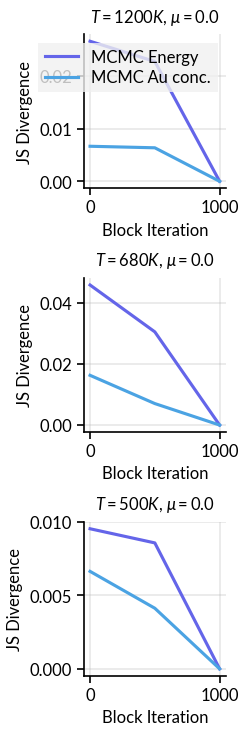

In [20]:
# ============================================================================
# Plot: JS Divergence over Block Iterations
# ============================================================================
js_color_dict = {"MCMC Energy": "C0", "MCMC Au_conc": "C1"}

fig, ax = plt.subplots(
    len(all_temps),
    len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained",
)

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        is_first_panel = i == 0 and j == 0
        labels = (
            ("MCMC Energy", "MCMC Au conc.") if is_first_panel else (None, None)
        )

        ax[i, j].plot(
            step_number_list,
            js_div_energy[key],
            label=labels[0],
            color=js_color_dict["MCMC Energy"],
        )
        ax[i, j].plot(
            step_number_list,
            js_div_Au_conc[key],
            label=labels[1],
            color=js_color_dict["MCMC Au_conc"],
        )

        style_subplot_axes(
            ax[i, j],
            xlabel="Block Iteration",
            ylabel="JS Divergence",
            title=format_subplot_title(temp, chem_pot),
        )

create_legend(fig, ax)
plt.show()
plt.close(fig)

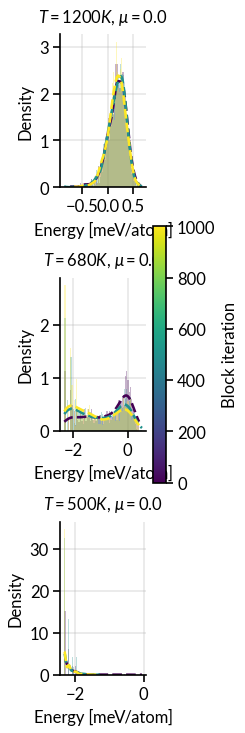

In [21]:
# ============================================================================
# Plot: MCMC Energy Distribution Evolution over Block Iterations
# ============================================================================
# from snowyflow.tools.ising_eval import get_periodic_table_colormap

# cmap = get_periodic_table_colormap()
cmap = plt.cm.viridis

# Extract all block step numbers for normalization
all_plot_steps = []
for labels in mc_labels_to_plot.values():
    for label in labels:
        try:
            all_plot_steps.append(int(label.split()[-1]))
        except (ValueError, IndexError):
            all_plot_steps.append(0)

norm = (
    plt.Normalize(vmin=min(all_plot_steps), vmax=max(all_plot_steps))
    if all_plot_steps
    else plt.Normalize(vmin=0, vmax=1)
)

fig, ax = plt.subplots(
    len(all_temps),
    len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained",
)

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        labels = mc_labels_to_plot[key]
        energies = mc_energies_to_plot[key]

        # Extract block steps for this panel
        block_steps = []
        for label in labels:
            try:
                block_steps.append(int(label.split()[-1]))
            except (ValueError, IndexError):
                block_steps.append(0)

        # Plot histograms for each block iteration
        is_first_panel = i == 0 and j == 0
        for k, label in enumerate(labels):
            energy_vals = energies[k]
            color = cmap(norm(block_steps[k])) if block_steps else cmap(0.5)
            _safe_hist(
                ax[i, j],
                energy_vals,
                label=label if is_first_panel else None,
                color=color,
            )

        style_subplot_axes(
            ax[i, j],
            xlabel="Energy [meV/atom]",
            ylabel="Density",
            title=format_subplot_title(temp, chem_pot),
        )

# Add colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax.ravel().tolist(), shrink=0.8, label="Block iteration")

fig.show()
# plt.close(fig)

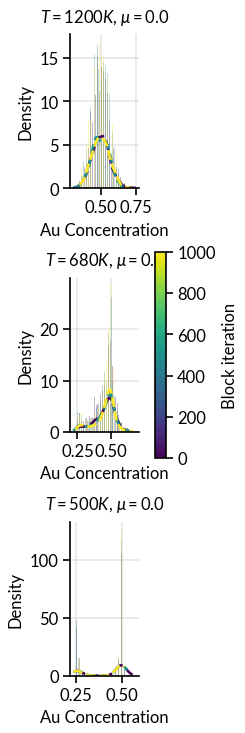

In [22]:
# ============================================================================
# Plot: MCMC Au Concentration Distribution Evolution over Block Iterations
# ============================================================================
fig, ax = plt.subplots(
    len(all_temps),
    len(all_chem_pots),
    figsize=(FIG_WIDTH * len(all_chem_pots), FIG_HEIGHT * len(all_temps)),
    layout="constrained",
)

# Ensure ax is always 2D for consistent indexing
if not hasattr(ax, 'ndim'):
    # Single axes object (1x1 subplot)
    ax = np.array([[ax]])
elif ax.ndim == 1:
    # 1D array - reshape to 2D
    if len(all_chem_pots) == 1:
        ax = ax[:, np.newaxis]
    elif len(all_temps) == 1:
        ax = ax[np.newaxis, :]

for i, temp in enumerate(reversed(all_temps)):
    for j, chem_pot in enumerate(all_chem_pots):
        key = f"{temp:.1f}K_mu{chem_pot:.2f}"
        labels = mc_labels_to_plot[key]
        Au_concs = mc_Au_conc_to_plot[key]

        # Extract block steps for this panel
        block_steps = []
        for label in labels:
            try:
                block_steps.append(int(label.split()[-1]))
            except (ValueError, IndexError):
                block_steps.append(0)

        # Plot histograms for each block iteration
        is_first_panel = i == 0 and j == 0
        for k, label in enumerate(labels):
            Au_conc_vals = Au_concs[k]
            color = cmap(norm(block_steps[k])) if block_steps else cmap(0.5)
            _safe_hist(
                ax[i, j],
                Au_conc_vals,
                label=label if is_first_panel else None,
                color=color,
            )

        style_subplot_axes(
            ax[i, j],
            xlabel="Au Concentration",
            ylabel="Density",
            title=format_subplot_title(temp, chem_pot),
        )

# Add colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, ax=ax.ravel().tolist(), shrink=0.8, label="Block iteration")

fig.show()
# plt.close(fig)